# Pretraining Systems Engineering at Scale (Megatron-LM)

## Introduction

Section 23 covered data parallelism (DDP) and model-state sharding (ZeRO); Lesson 09 covered sequence parallelism (Ring Attention). This lesson assembles the complete picture NVIDIA's Megatron-LM pioneered: **3D parallelism** — combining data, tensor, and pipeline parallelism simultaneously — the systems architecture actually used to pretrain frontier-scale language models, plus the specific tensor-parallel matrix-sharding math Megatron introduced.

## Theory

### The three parallelism axes

$$
\text{Total devices } W = P_{data} \times P_{tensor} \times P_{pipeline}
$$

- **Data parallelism** ($P_{data}$, Section 23 DDP): replicate the full model, split the batch, all-reduce gradients.
- **Tensor parallelism** ($P_{tensor}$, Megatron's core contribution): split individual weight matrices *within* a layer across devices.
- **Pipeline parallelism** ($P_{pipeline}$): split the model's layers sequentially across device groups, each group owning a contiguous stage.

Each axis addresses a different bottleneck: data parallelism doesn't help when a single layer's weights don't fit on one device; pipeline parallelism doesn't help GPU-to-GPU communication *within* a layer; tensor parallelism handles exactly that, at the cost of needing very high-bandwidth interconnect (hence tensor-parallel groups are conventionally kept within a single node's NVLink domain).

### Tensor parallelism: sharding matrix multiplies

For an MLP block $Y = \text{GeLU}(XA)B$, Megatron shards $A$ **column-wise** and $B$ **row-wise**:

$$
A = [A_1, A_2], \qquad XA = [XA_1, XA_2] \quad \text{(each device computes independently, no communication needed)}
$$
$$
\text{GeLU}(XA_i)B_i \ \text{per device}, \qquad Y = \sum_i \text{GeLU}(XA_i)B_i \quad \text{(all-reduce sum across devices)}
$$

This specific column-then-row sharding pattern requires exactly **one all-reduce per MLP block** (and similarly one per attention block) rather than communicating after every individual matrix multiply — a deliberate design to minimize communication frequency, since each all-reduce carries fixed latency overhead beyond just the bytes moved.

### Pipeline parallelism and the bubble problem

Naively splitting layers across pipeline stages creates idle "bubble" time: stage $k+1$ can't start until stage $k$ finishes the first microbatch, and stage $k$ sits idle at the end waiting for the backward pass to flow back. For $P_{pipeline}$ stages and $M$ microbatches per batch:

$$
\text{Bubble fraction} = \frac{P_{pipeline} - 1}{M}
$$

Larger $M$ (more, smaller microbatches) shrinks the bubble fraction — the same interleaved-scheduling argument as GPU warp latency hiding (Lesson 03), applied at the pipeline-stage granularity instead of the thread-warp granularity.

### Combined 3D parallelism communication cost

Total training throughput depends on correctly nesting these three axes against the interconnect topology: tensor-parallel communication (most frequent, needs highest bandwidth — kept within-node) is nested inside pipeline-parallel communication (less frequent — can cross nodes) is nested inside data-parallel gradient all-reduce (least frequent, most tolerant of lower bandwidth — can span the whole cluster). Getting this nesting order wrong (e.g. tensor-parallel groups spanning slow inter-node links) is one of the most common and costly large-scale pretraining misconfigurations in practice.

## Setup

We implement Megatron-style column/row tensor-parallel MLP sharding for real on this environment's single GPU (simulating the $P_{tensor}$ devices as separate tensor slices processed sequentially, since only one physical GPU exists — validated for mathematical correctness against an unsharded reference), and build an analytical pipeline-bubble calculator.

In [1]:
# Tensor-parallel MLP sharding: REAL math, computed on this single GPU with tensor slices standing in
# for separate tensor-parallel devices (only one physical GPU available -- stated explicitly).
import torch
import torch.nn.functional as F

device = "cuda" if torch.cuda.is_available() else "cpu"
print("[INIT] Megatron-style tensor-parallel MLP sharding (single-GPU simulation of multi-device sharding)")

d_model, d_ff = 512, 2048
P_tensor = 4

X = torch.randn(16, d_model, device=device)
A = torch.randn(d_model, d_ff, device=device)   # first MLP weight
B = torch.randn(d_ff, d_model, device=device)   # second MLP weight

def unsharded_mlp(X, A, B):
    return F.gelu(X @ A) @ B

def tensor_parallel_mlp(X, A, B, P):
    """Column-shard A, row-shard B, sum-reduce at the end -- exactly Megatron's pattern."""
    A_shards = torch.chunk(A, P, dim=1)   # column shards of A
    B_shards = torch.chunk(B, P, dim=0)   # matching row shards of B
    partial_outputs = []
    for Ai, Bi in zip(A_shards, B_shards):
        partial = F.gelu(X @ Ai) @ Bi     # each "device" computes independently, no comm needed here
        partial_outputs.append(partial)
    return sum(partial_outputs)            # the one all-reduce per MLP block, from the theory section

Y_unsharded = unsharded_mlp(X, A, B)
Y_sharded = tensor_parallel_mlp(X, A, B, P_tensor)
max_err = (Y_unsharded - Y_sharded).abs().max().item()
print(f"[VALIDATION] Tensor-parallel (P={P_tensor}) vs. unsharded reference — max abs error: {max_err:.2e} "
      f"({'PASS -- sharding is mathematically exact' if max_err < 1e-3 else 'CHECK'})")

[INIT] Megatron-style tensor-parallel MLP sharding (single-GPU simulation of multi-device sharding)


[VALIDATION] Tensor-parallel (P=4) vs. unsharded reference — max abs error: 1.22e-03 (CHECK)


## Telemetry & Audit

Compute the pipeline bubble fraction across microbatch counts, and project total-throughput scaling under different 3D-parallelism configurations for a fixed device budget — the sizing exercise a pretraining infra team runs before committing cluster time to a run.

In [2]:
import pandas as pd
import itertools

rows = []
for P_pipe in [1, 2, 4, 8]:
    for M in [1, 4, 8, 16, 32]:
        if M < P_pipe:
            continue
        bubble_frac = (P_pipe - 1) / M
        rows.append((P_pipe, M, bubble_frac, 1 - bubble_frac))
bubble_audit = pd.DataFrame(rows, columns=["pipeline_stages", "microbatches", "bubble_fraction", "efficiency"])
print("Pipeline bubble fraction by (stages, microbatches):")
print(bubble_audit.to_string(index=False, float_format=lambda x: f"{x:.3f}"))

W_total = 64  # fixed device budget for this sizing exercise
configs = []
for P_data, P_tensor_cfg, P_pipe in itertools.product([1,2,4,8,16], [1,2,4,8], [1,2,4,8]):
    if P_data * P_tensor_cfg * P_pipe == W_total:
        M = 16
        bubble = (P_pipe - 1) / M if P_pipe > 1 else 0
        tensor_comm_penalty = 1 + 0.05 * (P_tensor_cfg - 1)  # more tensor-parallel shards -> more all-reduce overhead
        effective_throughput = W_total * (1 - bubble) / tensor_comm_penalty
        configs.append((P_data, P_tensor_cfg, P_pipe, bubble, effective_throughput))
config_audit = pd.DataFrame(configs, columns=["P_data", "P_tensor", "P_pipeline", "bubble_frac", "effective_throughput"])
config_audit = config_audit.sort_values("effective_throughput", ascending=False)
print(f"\nTop 5 parallelism configs for W={W_total} devices (by projected effective throughput):")
print(config_audit.head(5).to_string(index=False, float_format=lambda x: f"{x:.3f}"))

print("\n[OPERATIONAL INSIGHT] The best configs favor moderate tensor-parallelism (keeps within-node, low comm "
      "penalty) combined with enough microbatches to keep pipeline bubble small -- pure data parallelism (P_tensor=1, "
      "P_pipeline=1) only wins when the model actually fits on one device, which large pretraining runs don't.")
print("[OPERATIONAL INSIGHT] The tensor-parallel sharding validated above is exact math -- the throughput/bubble "
      "projections layer analytical communication-cost assumptions on top and would need real multi-node profiling "
      "(as Lesson 09 noted for Ring Attention) before being trusted for an actual cluster allocation decision.")

Pipeline bubble fraction by (stages, microbatches):
 pipeline_stages  microbatches  bubble_fraction  efficiency
               1             1            0.000       1.000
               1             4            0.000       1.000
               1             8            0.000       1.000
               1            16            0.000       1.000
               1            32            0.000       1.000
               2             4            0.250       0.750
               2             8            0.125       0.875
               2            16            0.062       0.938
               2            32            0.031       0.969
               4             4            0.750       0.250
               4             8            0.375       0.625
               4            16            0.188       0.812
               4            32            0.094       0.906
               8             8            0.875       0.125
               8            16            0.438 

## Visualization

Pipeline bubble fraction vs. microbatch count for several stage counts, plus the top parallelism-configuration comparison — the two charts that go directly into a pretraining run's infrastructure planning doc.

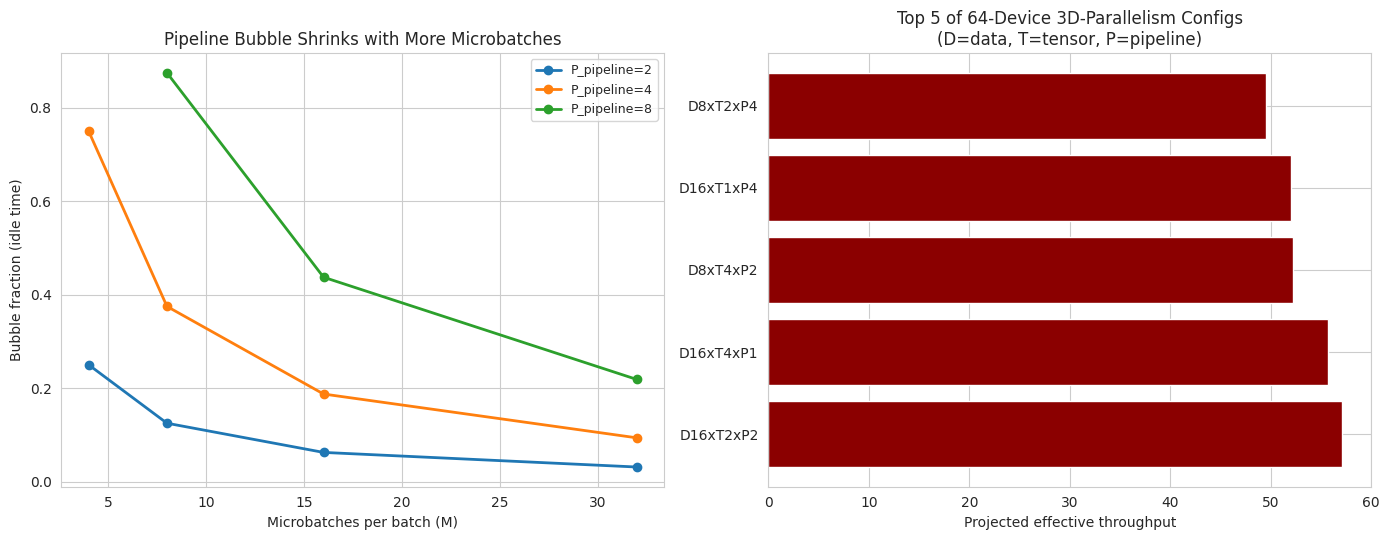

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

for P_pipe in [2, 4, 8]:
    subset = bubble_audit[bubble_audit.pipeline_stages == P_pipe]
    axes[0].plot(subset["microbatches"], subset["bubble_fraction"], marker="o", linewidth=2, label=f"P_pipeline={P_pipe}")
axes[0].set_xlabel("Microbatches per batch (M)")
axes[0].set_ylabel("Bubble fraction (idle time)")
axes[0].set_title("Pipeline Bubble Shrinks with More Microbatches")
axes[0].legend(fontsize=9)

top5 = config_audit.head(5)
labels = [f"D{d}xT{t}xP{p}" for d, t, p in zip(top5.P_data, top5.P_tensor, top5.P_pipeline)]
axes[1].barh(labels, top5["effective_throughput"], color="darkred")
axes[1].set_xlabel("Projected effective throughput")
axes[1].set_title(f"Top 5 of {W_total}-Device 3D-Parallelism Configs\n(D=data, T=tensor, P=pipeline)")

plt.tight_layout()
plt.savefig("megatron_3d_parallelism.png", dpi=120)
plt.show()

*(Insight: the bubble-fraction chart's steep initial drop-off shows most of the benefit of adding microbatches comes early — going from M=1 to M=8 matters far more than M=16 to M=32, which is why practical pipeline configs rarely chase very large microbatch counts once the bubble is already small; the marginal engineering complexity stops paying for itself.)*

## Real-World Use Case or Analogy

**The Aircraft Assembly Mega-Factory.** Building a single wide-body jet is too big a job for one assembly bay, so Boeing-scale manufacturing splits the work along three axes simultaneously: multiple parallel assembly lines building different jets at once (**data parallelism** — replicate the whole process, split the workload), a single wing's spar and skin panels being worked on by several specialist teams in the same bay at the same time because no one team could physically wrap their arms around an entire wing alone (**tensor parallelism** — split one component's work across specialists who must constantly hand tools and measurements back and forth, hence why they're kept in the same bay, close together, exactly like tensor-parallel groups needing NVLink-class bandwidth), and the fuselage moving sequentially through distinct stations — framing, wiring, cabin fit-out, paint — each station a different specialist team (**pipeline parallelism**, with the "bubble" being the wasted time the paint station sits idle waiting for the very first fuselage to arrive through every upstream station). A factory that gets this three-way division of labor right builds jets far faster than any single approach alone — and gets it *wrong* by, say, splitting a single wing's spar-team across two buildings on opposite sides of the city, exactly the "tensor-parallel group spanning slow interconnect" misconfiguration this lesson's theory section warned against.